In [1]:
from loss import *
from methods import *
from methods_ada import *

import matplotlib.pyplot as plt
import seaborn as sns
colors = sns.color_palette("colorblind")
colors = sns.color_palette("bright")
markers = ['o', '^', 'v', '<', '>', 's', 'D', 'd', 'p', 'h', 'H', '8', 'X', '*', '.', 'P', 'x', '+', '1', '2', '3', '4', '|', '_']
colors = sns.color_palette("bright", n_colors=len(markers))

seed = 3107
save_flag = False

/home/dimoik/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Deterministic

In [2]:
np.random.seed(seed)

# Problem Params
n = 100
d = n
lambd_reg = 0
cond_num = 10**1
cons = True
loss = RidgeRegression(n, d, lambd_reg, cond=cond_num, consistent=cons)

x0 = np.random.randn(loss.d)
f0 = loss.func(x0, np.arange(loss.n))

mu = loss.mu
L = loss.L
print(f"{loss.name}: mu={loss.mu}, L={loss.L}")

Ridge Regression: mu=0.0010000000000000052, L=0.09999999999999856


### Theory Comparison

In [3]:
np.random.seed(seed)

# Running Params
epochs = 100
trials = 1
bs = n

T = epochs * n
# record_f = np.arange(0, T+1)
record_f = np.arange(0, T+1, n)

names = []
fs = []

lambd = 0.0 # USAM

# USAM - Andriushchenko (2022)
rho = 1/(2*L)
gamma = 1/(2*L)
name, f = Unified_SAM(loss, trials, record_f, x0, gamma, rho, lambd, bs)
names.append(name);fs.append(f)
print(name + ' [Completed]')

# USAM - Khanh (2024)
rho = 1/(2*L)
gamma = 2/(9*L)
name, f = Unified_SAM(loss, trials, record_f, x0, gamma, rho, lambd, bs)
names.append(name);fs.append(f)
print(name + ' [Completed]')

# USAM - Oikonomou (2025)
rho = 1/(6*L)
gamma = (1-3*L*rho)/(2*L*(2*L**2*rho**2+1))
name, f = Unified_SAM(loss, trials, record_f, x0, gamma, rho, lambd, bs)
names.append(name);fs.append(f)
print(name + ' [Completed]')

# USAM - PS (2026)
rho = 1/(2*L)
if cons:
    f_star = 0
else:
    f_star = min([fs[j].min() for j in range(len(names))])
name, f = Unified_SAM_SPS(loss, trials, record_f, x0, rho, lambd, f_star, bs)
names.append(name);fs.append(f)
print(name + ' [Completed]')

Unified SAM, $\lambda=0.0$, $\rho=5.000$, $\gamma=5.000$ [Completed]
Unified SAM, $\lambda=0.0$, $\rho=5.000$, $\gamma=2.222$ [Completed]
Unified SAM, $\lambda=0.0$, $\rho=1.667$, $\gamma=2.368$ [Completed]
Unified SAM SPS, $\lambda=0.0$, $\rho=5.000$ [Completed]


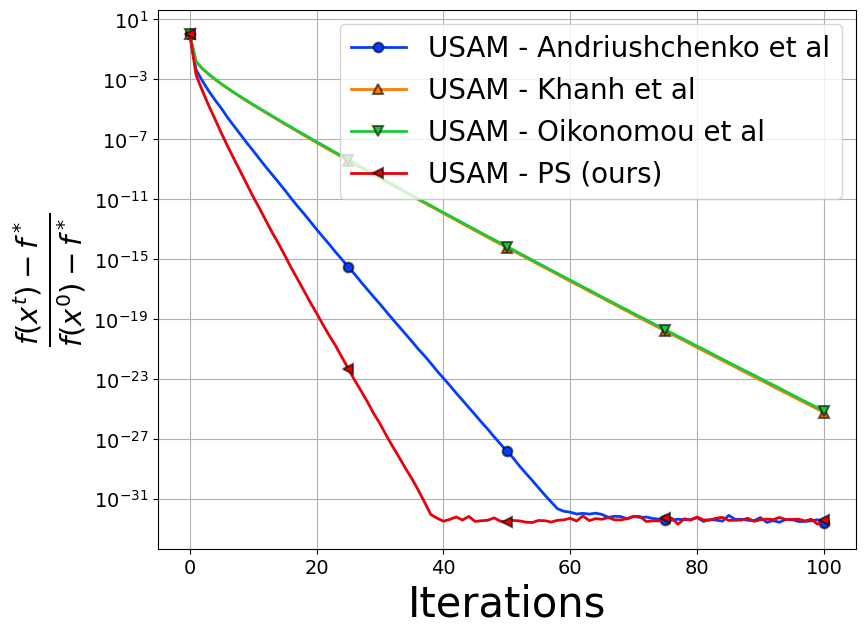

In [4]:
if cons:
    f_star = 0
else:
    f_star = min([fs[j].min() for j in range(len(names))])
# Plotting Params
figs = (9, 7)
font_size = 30

# Plotting
fig, ax = plt.subplots(figsize=figs)
scale = 1

curve_names = ['USAM - Andriushchenko et al', 'USAM - Khanh et al', 'USAM - Oikonomou et al', 'USAM - PS (ours)']
for j in range(len(names)):
# for j in [1]:
    plt.plot(range(len(fs[j])), (fs[j]-f_star)/(f0-f_star), color = colors[j], linewidth=2, label=curve_names[j], markevery=np.linspace(0, len(record_f)-1, 5, dtype=int), marker=markers[j], markersize=7, markeredgewidth=1.5, markeredgecolor=[0,0,0,0.6])

plt.tick_params(axis='both', labelsize=14)
plt.yscale("log")
plt.xlabel('Iterations', fontsize=font_size)
plt.ylabel(r'$\frac{f(x^t)-f^*}{f(x^0)-f^*}$', fontsize=font_size)
plt.legend(fontsize=20)
plt.grid(True)

if save_flag:
    plt.savefig('figures/usam_theory_det.pdf', bbox_inches='tight')

### Adaptive Comparison

In [5]:
np.random.seed(seed)

# Running Params
epochs = 100
trials = 1
bs = n

T = epochs * n
# record_f = np.arange(0, T+1)
record_f = np.arange(0, T+1, n)

names = []
fs = []


eps = 1e-12
# AdaSAM
gamma = 1e-2
# gamma_list = [1e-3, 1e-2, 1e-1, 1e0]
rho = 0.01
# rho_list = [0.01, 0.05, 0.1]
beta1 = 0.9
beta2 = 0.999
name, f = AdaSAM(loss, trials, record_f, x0, gamma, rho, beta1, beta2, eps, bs)
names.append(name);fs.append(f)
print(name + ' [Completed]')

# LightSAM-I
eta = 5.0
# eta_list = [0.1, 0.5, 1.0, 5.0]
rho = 0.1
# rho_list = [0.01, 0.05, 0.1]
name, f = LightSAM_I(loss, trials, record_f, x0, eta, rho, eps, bs)
names.append(name);fs.append(f)
print(name + ' [Completed]')

# LightSAM-II
eta = 0.5
# eta_list = [0.01, 0.05, 0.1, 0.5]
rho = 0.01
# rho_list = [0.001, 0.01, 0.05, 0.1]
name, f = LightSAM_II(loss, trials, record_f, x0, eta, rho, eps, bs)
names.append(name);fs.append(f)
print(name + ' [Completed]')

# LightSAM-III
eta = 0.01
# eta_list = [1e-3, 1e-2, 1e-1]
rho = 0.01
# rho_list = [1e-3, 1e-2, 1e-1]
beta1 = 0.9
beta2 = 0.999
name, f = LightSAM_III(loss, trials, record_f, x0, eta, rho, beta1, beta2, eps, bs)
names.append(name);fs.append(f)
print(name + ' [Completed]')

# SA-SAM
eta0 = 1e-1
# eta0_list = [1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2]
name, f = SA_SAM(loss, trials, record_f, x0, eta0, bs)
names.append(name);fs.append(f)
print(name + ' [Completed]')

# USAM - PS
lambd = 0.0 # USAM
rho = 1e-1
# rho_list = [1e-3, 1e-2, 1e-1, 1e0]
if cons:
    f_star = 0
else:
    f_star = min([fs[j].min() for j in range(len(names))])
name, f = Unified_SAM_SPS(loss, trials, record_f, x0, rho, lambd, f_star, bs)
name = 'USAM-PS (ours)'
names.append(name);fs.append(f)
print(name + ' [Completed]')

AdaSAM [Completed]
LightSAM-I [Completed]
LightSAM-II (AdaGrad) [Completed]
LightSAM-III (Adam) [Completed]
SA-SAM [Completed]
USAM-PS (ours) [Completed]


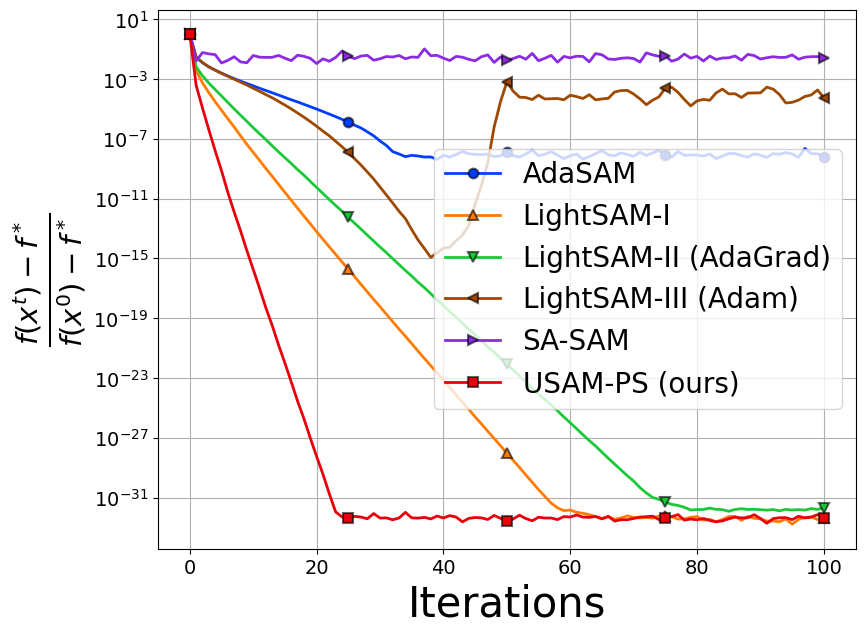

In [6]:
if cons:
    f_star = 0
else:
    f_star = min([fs[j].min() for j in range(len(names))])
# Plotting Params
figs = (9, 7)
font_size = 30

# Plotting
fig, ax = plt.subplots(figsize=figs)
scale = 1

# Make USAM-PS (ours) red; swap with whichever slot currently holds red to avoid a clash
plot_colors = list(colors)
ps_idx = next(j for j, n in enumerate(names) if 'USAM-PS' in n)
red_idx = 3  # seaborn 'bright' palette: colors[3] is red
if ps_idx != red_idx:
    plot_colors[ps_idx], plot_colors[red_idx] = plot_colors[red_idx], plot_colors[ps_idx]

for j in range(len(names)):
# for j in [1]:
    # plt.plot(range(len(fs[j])), (fs[j]-f_star)/(f0-f_star), color = colors[j], linewidth=2, label=curve_names[j], markevery=np.linspace(0, len(record_f)-1, 5, dtype=int), marker=markers[j], markersize=7, markeredgewidth=1.5, markeredgecolor=[0,0,0,0.6])
    plt.plot(range(len(fs[j])), (fs[j]-f_star)/(f0-f_star), color = plot_colors[j], linewidth=2, label=names[j], markevery=np.linspace(0, len(record_f)-1, 5, dtype=int), marker=markers[j], markersize=7, markeredgewidth=1.5, markeredgecolor=[0,0,0,0.6])

plt.tick_params(axis='both', labelsize=14)
plt.yscale("log")
plt.xlabel('Iterations', fontsize=font_size)
plt.ylabel(r'$\frac{f(x^t)-f^*}{f(x^0)-f^*}$', fontsize=font_size)
plt.legend(fontsize=20)
plt.grid(True)

if save_flag:
    plt.savefig('figures/ada_comparison_det.pdf', bbox_inches='tight')

## Stochastic

In [2]:
np.random.seed(seed)

# Problem Params
n = 100
d = n
lambd_reg = 0.1/n
cond_num = 10**1
cons = False
loss = RidgeRegression(n, d, lambd_reg, cond=cond_num, consistent=cons)

loss = RidgeRegression(n, d, lambd_reg)

x0 = np.random.randn(loss.d)
f0 = loss.func(x0, np.arange(loss.n))

mu = loss.mu
L = loss.L
print(f"{loss.name}: mu={loss.mu}, L={loss.L}")

Ridge Regression: mu=0.001000353023482123, L=3.591274668002365


### Theory Comparison

In [8]:
np.random.seed(seed)

# Running Params
epochs = 100
trials = 5
bs = 10

T = epochs * n
record_f = np.arange(0, T+1, n)
# record_f = np.arange(0, T+1)

names = []
fs = []

lambd = 0.0
Lmax = loss.L_max

# USAM - Andriushchenko
name, f = USAM_andr(loss, trials, record_f, x0, bs)
names.append(name);fs.append(f)
print(name + ' [Completed]')

# USAM - Oikonomou
rho = mu/(2*Lmax*(mu+2*Lmax))
gamma = (mu-Lmax*rho*(mu+2*Lmax))/(2*Lmax**2*(2*Lmax**2*rho**2+1))
name, f = Unified_SAM(loss, trials, record_f, x0, gamma, rho, lambd, bs)
names.append(name);fs.append(f)
print(name + ' [Completed]')

# PolyakUSAM
rho = 1/(2*Lmax)
gamma_b = 1.0
if cons:
    f_star = 0
else:
    f_star = min([fs[j].min() for j in range(len(names))])
name, f = Unified_SAM_SPS_max(loss, trials, record_f, x0, rho, lambd, 0, gamma_b, bs)
names.append(name);fs.append(f)
print(name + ' [Completed]')

f_star = min([fs[j].min() for j in range(len(names))])

USAM Andriushchenko Stochastic [Completed]
Unified SAM, $\lambda=0.0$, $\rho=0.000$, $\gamma=0.000$ [Completed]
Unified SAM SPS, $\lambda=0.0$, $\rho=0.004$ [Completed]


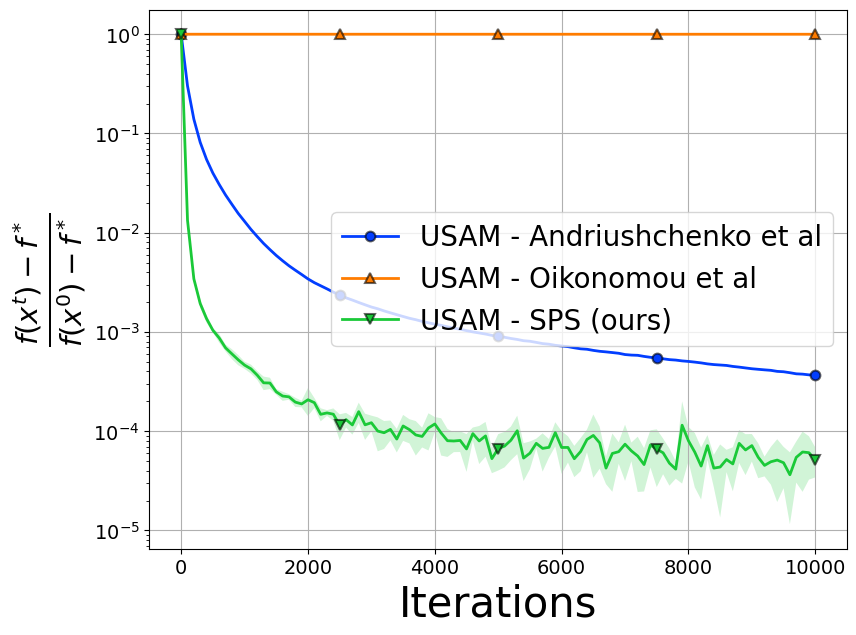

In [9]:
# Plotting Params
figs = (9, 7)
font_size = 30
scale = 1

# Plotting
fig, ax = plt.subplots(figsize=figs)
scale = 1
eps = 1e-16
curve_names = ['USAM - Andriushchenko et al', 'USAM - Oikonomou et al', 'USAM - SPS (ours)']
for j in range(len(names)):
    quantity = (fs[j]-f_star)/(f0-f_star)
    mean_f = np.mean(quantity, axis=1)
    std_f = np.std(quantity, axis=1)
    plt.fill_between(record_f, mean_f-scale*std_f, mean_f+scale*std_f, alpha=0.2, fc=colors[j])
    plt.plot(record_f, mean_f, color = colors[j], linewidth=2, label=curve_names[j], markevery=np.linspace(0, len(record_f)-1, 5, dtype=int), marker=markers[j], markersize=7, markeredgewidth=1.5, markeredgecolor=[0,0,0,0.6])

plt.tick_params(axis='both', labelsize=14)
plt.yscale("log")
plt.xlabel('Iterations', fontsize=font_size)
plt.ylabel(r'$\frac{f(x^t)-f^*}{f(x^0)-f^*}$', fontsize=font_size)
plt.legend(fontsize=20)
plt.grid(True)

if save_flag:
    plt.savefig('figures/usam_theory_stoch.pdf', bbox_inches='tight')

### Adaptive

In [3]:
np.random.seed(seed)

# Running Params
epochs = 500
trials = 3
bs = 10

T = epochs * n
# record_f = np.arange(0, T+1)
record_f = np.arange(0, T+1, n)

names = []
fs = []
Lmax = loss.L_max



eps = 1e-12
# AdaSAM
gamma = 1e-2
# gamma_list = [1e-3, 1e-2, 1e-1, 1e0]
rho = 0.01
# rho_list = [0.01, 0.05, 0.1]
beta1 = 0.9
beta2 = 0.999
name, f = AdaSAM(loss, trials, record_f, x0, gamma, rho, beta1, beta2, eps, bs)
names.append(name);fs.append(f)
print(name + ' [Completed]')

# LightSAM-I
eta = 5.0
# eta_list = [0.1, 0.5, 1.0, 5.0]
rho = 0.01
# rho_list = [0.01, 0.05, 0.1]
name, f = LightSAM_I(loss, trials, record_f, x0, eta, rho, eps, bs)
names.append(name);fs.append(f)
print(name + ' [Completed]')

# LightSAM-II
eta = 0.5
# eta_list = [0.01, 0.05, 0.1, 0.5]
rho = 0.1
# rho_list = [0.001, 0.01, 0.05, 0.1]
name, f = LightSAM_II(loss, trials, record_f, x0, eta, rho, eps, bs)
names.append(name);fs.append(f)
print(name + ' [Completed]')

# LightSAM-III
eta = 0.01
# eta_list = [1e-3, 1e-2, 1e-1]
rho = 0.001
# rho_list = [1e-3, 1e-2, 1e-1]
beta1 = 0.9
beta2 = 0.999
name, f = LightSAM_III(loss, trials, record_f, x0, eta, rho, beta1, beta2, eps, bs)
names.append(name);fs.append(f)
print(name + ' [Completed]')

# SA-SAM
eta0 = 1e-1
# eta0_list = [1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2]
name, f = SA_SAM(loss, trials, record_f, x0, eta0, bs)
names.append(name);fs.append(f)
print(name + ' [Completed]')

# USAM - PS
lambd = 0.0 # USAM
rho = 0.01
# rho_list = [1e-3, 1e-2]
gamma_b = 1.0
if cons:
    f_star = 0
else:
    f_star = min([fs[j].min() for j in range(len(names))])
name, f = Unified_SAM_SPS_max(loss, trials, record_f, x0, rho, lambd, 0, gamma_b, bs)
name = 'USAM-SPS (ours)'
names.append(name);fs.append(f)
print(name + ' [Completed]')

f_star = min([fs[j].min() for j in range(len(names))])

AdaSAM [Completed]
LightSAM-I [Completed]
LightSAM-II (AdaGrad) [Completed]
LightSAM-III (Adam) [Completed]
SA-SAM [Completed]
USAM-SPS (ours) [Completed]


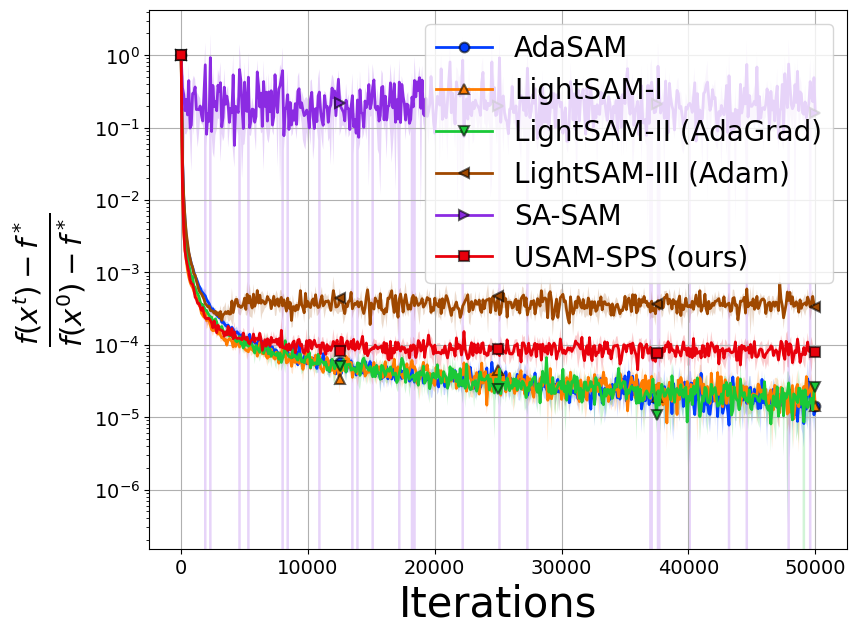

In [4]:
# Plotting Params
figs = (9, 7)
font_size = 30
scale = 1

# Plotting
fig, ax = plt.subplots(figsize=figs)
scale = 1

# Make USAM-SPS (ours) red; swap with whichever slot currently holds red to avoid a clash
plot_colors = list(colors)
ps_idx = next(j for j, n in enumerate(names) if 'USAM-SPS' in n)
red_idx = 3  # seaborn 'bright' palette: colors[3] is red
if ps_idx != red_idx:
    plot_colors[ps_idx], plot_colors[red_idx] = plot_colors[red_idx], plot_colors[ps_idx]

for j in range(len(names)):
    quantity = (fs[j]-f_star)/(f0-f_star)
    mean_f = np.mean(quantity, axis=1)
    std_f = np.std(quantity, axis=1)
    plt.fill_between(record_f, mean_f-scale*std_f, mean_f+scale*std_f, alpha=0.2, fc=plot_colors[j])
    plt.plot(record_f, mean_f, color = plot_colors[j], linewidth=2, label=names[j], markevery=np.linspace(0, len(record_f)-1, 5, dtype=int), marker=markers[j], markersize=7, markeredgewidth=1.5, markeredgecolor=[0,0,0,0.6])

plt.tick_params(axis='both', labelsize=14)
plt.yscale("log")
plt.xlabel('Iterations', fontsize=font_size)
plt.ylabel(r'$\frac{f(x^t)-f^*}{f(x^0)-f^*}$', fontsize=font_size)
plt.legend(fontsize=20)
plt.grid(True)

if save_flag:
    plt.savefig('figures/ada_comparison_stoch.pdf', bbox_inches='tight')